
========== FIRST 5 ROWS ==========

   customer_id signup_date country  age  gender loyalty_tier  \
0            1  08-04-2021      BR   48    Male       Bronze   
1            2  28-04-2023      IN   36  Female       Silver   
2            3  18-12-2022      UK   35  Female       Silver   
3            4  26-04-2022      US   45    Male       Silver   
4            5  20-04-2022      IN   53    Male       Silver   

  acquisition_channel  
0            Referral  
1             Organic  
2             Organic  
3         Paid Search  
4             Organic  

========== LOYALTY TIER COUNTS ==========

loyalty_tier
Bronze      60276
Silver      24912
Gold        11794
Platinum     3018
Name: count, dtype: int64


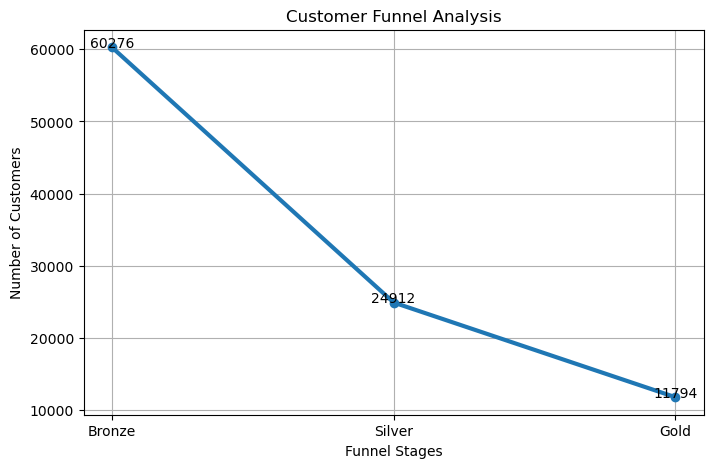


========== CHANNEL PERFORMANCE ==========

       Channel  Total_Customers
0        Email            14903
1      Organic            30200
2  Paid Search            29950
3     Referral             9968
4       Social            14979

========== GOLD CUSTOMER ANALYSIS ==========

       Channel  Gold_Customers
0        Email            1765
1      Organic            3548
2  Paid Search            3591
3     Referral            1163
4       Social            1727

========== CONVERSION RATES ==========

       Channel  Total_Customers  Gold_Customers  Conversion_Rate_%
0        Email            14903            1765          11.843253
1      Organic            30200            3548          11.748344
2  Paid Search            29950            3591          11.989983
3     Referral             9968            1163          11.667335
4       Social            14979            1727          11.529475


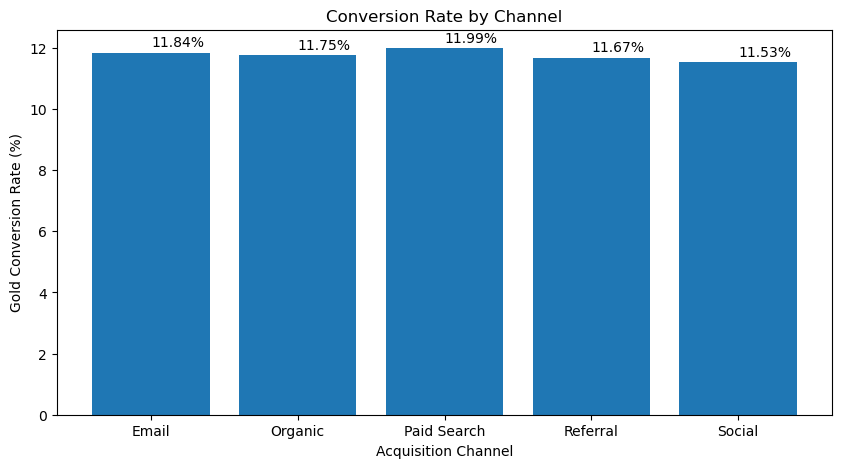


========== GENDER ANALYSIS ==========

gender
Female    48006
Male      48054
Other      3940
Name: customer_id, dtype: int64

========== COUNTRY ANALYSIS ==========

country
US    34931
IN    20089
UK    10155
BR    10002
CA     9906
DE     7896
AU     7021
Name: customer_id, dtype: int64

========== AGE ANALYSIS ==========

Average Customer Age: 35.22

========== DROP-OFF ANALYSIS ==========

Bronze to Silver Drop: 35364
Silver to Gold Drop: 13118

========== BEST CHANNEL ==========

Channel              Paid Search
Total_Customers            29950
Gold_Customers              3591
Conversion_Rate_%      11.989983
Name: 2, dtype: object

========== RECOMMENDATIONS ==========

1. Invest more in channels with higher Gold conversion.
2. Improve engagement strategies for Bronze users.
3. Target countries with higher customer counts.
4. Personalized campaigns may improve Silver-to-Gold conversion.
5. Retarget low-engagement users.

Report Saved Successfully!


In [1]:


import pandas as pd
import matplotlib.pyplot as plt
import zipfile
import os

df = pd.read_csv("sales.csv")

print("\n========== FIRST 5 ROWS ==========\n")
print(df.head())

tier_counts = df['loyalty_tier'].value_counts()

print("\n========== LOYALTY TIER COUNTS ==========\n")
print(tier_counts)


bronze_count = tier_counts.get('Bronze', 0)
silver_count = tier_counts.get('Silver', 0)
gold_count = tier_counts.get('Gold', 0)

funnel_stages = ['Bronze', 'Silver', 'Gold']
funnel_values = [bronze_count, silver_count, gold_count]


plt.figure(figsize=(8,5))

plt.plot(
    funnel_stages,
    funnel_values,
    marker='o',
    linewidth=3
)

plt.title("Customer Funnel Analysis")
plt.xlabel("Funnel Stages")
plt.ylabel("Number of Customers")

for i, value in enumerate(funnel_values):
    plt.text(i, value + 1, str(value), ha='center')

plt.grid(True)
plt.show()

channel_analysis = df.groupby(
    'acquisition_channel'
)['customer_id'].count().reset_index()

channel_analysis.columns = [
    'Channel',
    'Total_Customers'
]

print("\n========== CHANNEL PERFORMANCE ==========\n")
print(channel_analysis)


gold_customers = df[
    df['loyalty_tier'] == 'Gold'
]

gold_channel = gold_customers.groupby(
    'acquisition_channel'
)['customer_id'].count().reset_index()

gold_channel.columns = [
    'Channel',
    'Gold_Customers'
]

print("\n========== GOLD CUSTOMER ANALYSIS ==========\n")
print(gold_channel)


conversion = pd.merge(
    channel_analysis,
    gold_channel,
    on='Channel',
    how='left'
)

conversion['Gold_Customers'] = (
    conversion['Gold_Customers']
    .fillna(0)
)

conversion['Conversion_Rate_%'] = (
    conversion['Gold_Customers']
    / conversion['Total_Customers']
) * 100

print("\n========== CONVERSION RATES ==========\n")
print(conversion)

plt.figure(figsize=(10,5))

plt.bar(
    conversion['Channel'],
    conversion['Conversion_Rate_%']
)

plt.title("Conversion Rate by Channel")
plt.xlabel("Acquisition Channel")
plt.ylabel("Gold Conversion Rate (%)")

for i, value in enumerate(
    conversion['Conversion_Rate_%']
):
    plt.text(i, value + 0.2, f"{value:.2f}%")

plt.show()


gender_analysis = df.groupby(
    'gender'
)['customer_id'].count()

print("\n========== GENDER ANALYSIS ==========\n")
print(gender_analysis)

country_analysis = df.groupby(
    'country'
)['customer_id'].count().sort_values(
    ascending=False
)

print("\n========== COUNTRY ANALYSIS ==========\n")
print(country_analysis)

avg_age = df['age'].mean()

print("\n========== AGE ANALYSIS ==========\n")
print(f"Average Customer Age: {avg_age:.2f}")


bronze_to_silver_drop = bronze_count - silver_count
silver_to_gold_drop = silver_count - gold_count

print("\n========== DROP-OFF ANALYSIS ==========\n")

print(f"Bronze to Silver Drop: {bronze_to_silver_drop}")

print(f"Silver to Gold Drop: {silver_to_gold_drop}")


best_channel = conversion.loc[
    conversion['Conversion_Rate_%'].idxmax()
]

print("\n========== BEST CHANNEL ==========\n")

print(best_channel)

print("\n========== RECOMMENDATIONS ==========\n")

print("1. Invest more in channels with higher Gold conversion.")

print("2. Improve engagement strategies for Bronze users.")

print("3. Target countries with higher customer counts.")

print("4. Personalized campaigns may improve Silver-to-Gold conversion.")

print("5. Retarget low-engagement users.")

conversion.to_csv(
    "marketing_funnel_report.csv",
    index=False
)

print("\nReport Saved Successfully!")